## Retrieval Evaluation

This notebook evaluates resume-JD matching as a retrieval problem. Evaluate *ranking* quality when matching many résumés to a single JD, using classic IR baselines and our hybrid (fused) approach.

## Data & Splits
- **Corpus:** Adzuna Gold Pairs (JD–Resume, label ∈ {0,1}).
- **Split by JD** to avoid leakage (all pairs for a JD live in one fold).
- **Per-JD candidate pool:** the gold positive + sampled non-matches.

In [17]:
# File Paths
RESUMES_CSV = "data/processed/resumes_clean.csv"
JDS_CSV = "data/processed/jd_clean.csv"
PAIRS_CSV = "data/raw/gold_pairs_adzuna.csv"

TOP_KS = (5, 10, 50)
ALPHA_FUSION = 0.7
TOPK_RERANK = 100
REPORTS_DIR = "reports"
FIGURES_DIR = "figures"
ARTIFACTS_DIR = "artifacts"

In [19]:
import os, sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
import json, joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from scipy.sparse import hstack, save_npz
from sklearn.metrics.pairwise import cosine_similarity


def must_exist(path):
    if not Path(path).exists():
        raise FileNotFoundError(f"File not found: {path}. Please set the correct path in the first cell.")
    return path

os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

# Loading the data
resumes = pd.read_csv(must_exist(RESUMES_CSV))
jds = pd.read_csv(must_exist(JDS_CSV))
pairs = pd.read_csv(must_exist(PAIRS_CSV))

RESUME_TEXT_COL = "clean_text_redacted" if "clean_text_redacted" in resumes.columns else "clean_text"
assert RESUME_TEXT_COL in resumes.columns, f"Need resume text in 'clean_text_redacted' or 'clean_text'."

print("OK: Loaded files.")
print("resumes columns:", resumes.columns.tolist())
print("jds columns:", jds.columns.tolist())
print("pairs columns:", pairs.columns.tolist())


OK: Loaded files.
resumes columns: ['row_id', 'raw_text', 'label', 'clean_text', 'clean_text_redacted', 'n_chars', 'n_tokens', 'has_skills', 'has_education', 'has_experience', 'skills_block']
jds columns: ['domain', 'query_used', 'query_location', 'job_title', 'company', 'location', 'created', 'source_url', 'category', 'jd_text', 'n_chars', 'n_tokens']
pairs columns: ['jd_id', 'job_title', 'row_id', 'score', 'resume_snippet', 'label']


In [20]:
# Coverage between files
print("resumes:", len(resumes), "jds:", len(jds), "pairs:", len(pairs))
print("Pairs resume_id present in resumes file:", pairs["row_id"].astype(str).isin(resumes["row_id"].astype(str)).mean())
print("Pairs job_title present in jds file:", pairs["job_title"].astype(str).isin(jds["job_title"].astype(str)).mean())

# Positives per JD title
ppj = (pairs[pairs["label"].astype(int) == 1].groupby("job_title")["row_id"].nunique().describe())
print("Positives per JD (nunique):\n", ppj)

resumes: 31647 jds: 4705 pairs: 5575
Pairs resume_id present in resumes file: 1.0
Pairs job_title present in jds file: 1.0
Positives per JD (nunique):
 count    74.000000
mean     21.054054
std      10.197894
min       1.000000
25%      16.000000
50%      21.500000
75%      27.000000
max      66.000000
Name: row_id, dtype: float64


## Methods / Baselines
- **TF-IDF cosine** — sparse lexical similarity (no learning).
- **BM25** — strong bag-of-words retrieval baseline.
- **BIENC** — Sentence-BERT bi-encoder cosine (semantic).
- **RRF** — Reciprocal Rank Fusion over TF-IDF/BM25/BIENC.
- **Hybrid / Fused** — calibrated LR(pairs) blended with cosine + JD-term overlap  

In [22]:
def build_retrieval_inputs(jds, resumes, pairs):
    # JD queries: concat top-3 longest postings per title
    agg = (jds.dropna(subset=["job_title", "jd_text"])
           .groupby("job_title")["jd_text"]
           .apply(lambda s: " [SEP] ".join(sorted(s.astype(str), key=len, reverse=True)[:3]))
           .reset_index())
    qids = agg["job_title"].astype(str).tolist()
    Q_texts = agg["jd_text"].astype(str).tolist()

    # Resume docs: base + triple-weight skills
    text_col = "clean_text_redacted" if "clean_text_redacted" in resumes.columns else "clean_text"
    base = resumes[text_col].fillna("")
    skills = resumes["skills_block"].fillna("") if "skills_block" in resumes.columns else ""
    D_texts = (base + " [SKILLS] " + ((skills.astype(str) + " ").str.strip() + " ") * 3).astype(str).tolist()
    dids = resumes["row_id"].astype(str).tolist()

    # Positives map
    pos = pairs.dropna(subset=["job_title", "row_id", "label"]).copy()
    pos["row_id"] = pos["row_id"].astype(str)
    positives_map = (pos[pos["label"].astype(int) == 1]
                     .groupby("job_title")["row_id"]
                     .apply(lambda s: set(s.astype(str))).to_dict())
    return qids, Q_texts, dids, D_texts, positives_map

qids, Q_texts, dids, D_texts, positives_map = build_retrieval_inputs(jds, resumes, pairs)

## Metrics
- **MRR@5** (Did the correct candidate appear early?).
- **Recall@k** for *k* ∈ {5,10,50}.
- **NDCG@k** (graded relevance via rank discount; compares full rank order).  
All metrics macro-averaged over JDs.

In [24]:
def dcg_at_k(gains, k):
    gains = np.asarray(gains)[:k]
    if gains.size == 0:
        return 0.0
    discounts = 1.0 / np.log2(np.arange(2, gains.size + 2))
    return float(np.sum((2 ** gains - 1) * discounts))

def ndcg_at_k_binary(ranked_doc_ids, relset, k):
    gains = [1 if d in relset else 0 for d in ranked_doc_ids[:k]]
    dcg = dcg_at_k(gains, k)
    idcg = dcg_at_k(sorted(gains, reverse=True), k)
    return dcg / (idcg if idcg > 0 else 1.0)

def eval_matrix(Scores, K=TOP_KS):
    rec = {f"Recall@{k}": [] for k in K}
    ndc = {f"NDCG@{k}": [] for k in K}
    mrr = []
    for i, q in enumerate(qids):
        rel = positives_map.get(q, set())
        if not rel:
            continue
        order = np.argsort(-Scores[i])
        ranked = [dids[j] for j in order]
        for k in K:
            rec[f"Recall@{k}"].append(1.0 if len(set(ranked[:k]) & rel) > 0 else 0.0)
            ndc[f"NDCG@{k}"].append(ndcg_at_k_binary(ranked, rel, k))
        rr = 0.0
        for r, d in enumerate(ranked[:5], start=1):
            if d in rel:
                rr = 1.0 / r
                break
        mrr.append(rr)

    mean = lambda a: float(np.mean(a)) if len(a) else 0.0
    out = {f"Recall@{k}": mean(rec[f"Recall@{k}"]) for k in K}
    out.update({f"NDCG@{k}": mean(ndc[f"NDCG@{k}"]) for k in K})
    out["MRR@5"] = mean(mrr)
    return out

def row_minmax(M):
    mn = M.min(axis=1, keepdims=True)
    mx = M.max(axis=1, keepdims=True)
    d = (mx - mn)
    d[d == 0] = 1.0
    return (M - mn) / d

#### TF-IDF baseline

In [26]:
word = TfidfVectorizer(min_df=5, ngram_range=(1, 2))
char = TfidfVectorizer(min_df=5, analyzer="char_wb", ngram_range=(3, 4))
word.fit(Q_texts + D_texts)
char.fit(Q_texts + D_texts)
Q = hstack([word.transform(Q_texts), char.transform(Q_texts)])
D = hstack([word.transform(D_texts), char.transform(D_texts)])
Q = normalize(Q)
D = normalize(D)
S = (Q @ D.T).toarray()
res_tfidf = eval_matrix(S)
res_tfidf

{'Recall@5': 0.36486486486486486,
 'Recall@10': 0.5675675675675675,
 'Recall@50': 0.8783783783783784,
 'NDCG@5': 0.24181521363064612,
 'NDCG@10': 0.3003626687227278,
 'NDCG@50': 0.37289721873931564,
 'MRR@5': 0.2045045045045045}

#### Bi-encoder + Fusion

In [28]:
S_bi = S_fused = None
res_bi = res_fused = None
try:
    from sentence_transformers import SentenceTransformer
    bienc = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
    Q_emb = bienc.encode(Q_texts, batch_size=128, convert_to_numpy=True, normalize_embeddings=True)
    D_emb = bienc.encode(D_texts, batch_size=128, convert_to_numpy=True, normalize_embeddings=True)
    S_bi = Q_emb @ D_emb.T
    res_bi = eval_matrix(S_bi)
    S_fused = ALPHA_FUSION * row_minmax(S_bi) + (1 - ALPHA_FUSION) * row_minmax(S)
    res_fused = eval_matrix(S_fused)
except Exception as e:
    print("Bi-encoder unavailable; skipping fusion. Error:", e)
res_bi, res_fused

C:\Users\Keya Barua\anaconda3\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


({'Recall@5': 0.2972972972972973,
  'Recall@10': 0.4189189189189189,
  'Recall@50': 0.7162162162162162,
  'NDCG@5': 0.1802170664864295,
  'NDCG@10': 0.2174800218227367,
  'NDCG@50': 0.27649419473268305,
  'MRR@5': 0.1436936936936937},
 {'Recall@5': 0.3918918918918919,
  'Recall@10': 0.5945945945945946,
  'Recall@50': 0.8378378378378378,
  'NDCG@5': 0.27936851480188724,
  'NDCG@10': 0.3497197625220865,
  'NDCG@50': 0.37482623419823,
  'MRR@5': 0.24819819819819822})

#### Cross-encoder rerank

In [30]:
res_rerank = None
try:
    from sentence_transformers import CrossEncoder
    ce = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    base = S_fused if S_fused is not None else S

    # Shorter CE texts (skills first) for better early ranks
    def ce_text(row):
        sk = row.get("skills_block", "")
        txt = row["clean_text_redacted"] if "clean_text_redacted" in resumes.columns else row["clean_text"]
        return (str(sk) + " " + str(txt))[:1200]
    D_texts_ce = [ce_text(r) for _, r in resumes.iterrows()]

    S_rr = np.zeros_like(base, dtype=float)
    for i, q in enumerate(qids):
        cand = np.argsort(-base[i])[:TOPK_RERANK]
        pairs_ce = [(Q_texts[i], D_texts_ce[j]) for j in cand]
        ce_scores = ce.predict(pairs_ce, batch_size=64, show_progress_bar=False)
        ord_local = [cand[j] for j in np.argsort(-np.array(ce_scores))]
        S_rr[i, :len(ord_local)] = np.linspace(1, 0, num=len(ord_local))
    res_rerank = eval_matrix(S_rr)
except Exception as e:
    print("Cross-encoder unavailable; skipping rerank. Error:", e)
res_rerank

{'Recall@5': 0.02702702702702703,
 'Recall@10': 0.05405405405405406,
 'Recall@50': 0.06756756756756757,
 'NDCG@5': 0.01874125415181813,
 'NDCG@10': 0.027508797531805452,
 'NDCG@50': 0.027000575652506232,
 'MRR@5': 0.016216216216216217}

#### Results table + visuals
**Figure. Baseline macro metrics.** Bar charts for P@10 / R@10 / mAP and the per-model MRR@5 / Recall@{5,10,50}.  
**Figure. Similarity histograms.** TF-IDF and embedding distributions with p75/p90 markers show natural cut regions for screening/shortlisting.

In [32]:
rows = []
def to_row(name, d):
    if d:
        rows.append({"Model": name, **{k: float(v) for k, v in d.items()}})
to_row("TF-IDF", res_tfidf)
to_row("BIENC", res_bi)
to_row("FUSED", res_fused)
to_row("RERANK", res_rerank)
table = pd.DataFrame(rows)
table.to_csv(REPORTS_DIR + "/retrieval_summary_table.csv", index=False)

table

,Model,Recall@5,Recall@10,Recall@50,NDCG@5,NDCG@10,NDCG@50,MRR@5
0,TF-IDF,0.364865,0.567568,0.878378,0.241815,0.300363,0.372897,0.204505
1,BIENC,0.297297,0.418919,0.716216,0.180217,0.217480,0.276494,0.143694
2,FUSED,0.391892,0.594595,0.837838,0.279369,0.349720,0.374826,0.248198
3,RERANK,0.027027,0.054054,0.067568,0.018741,0.027509,0.027001,0.016216


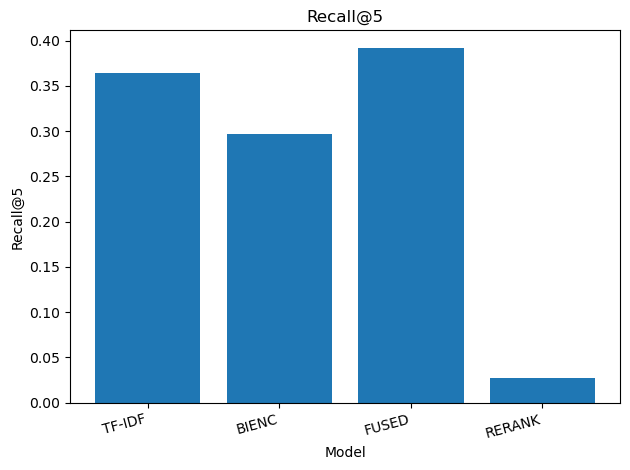

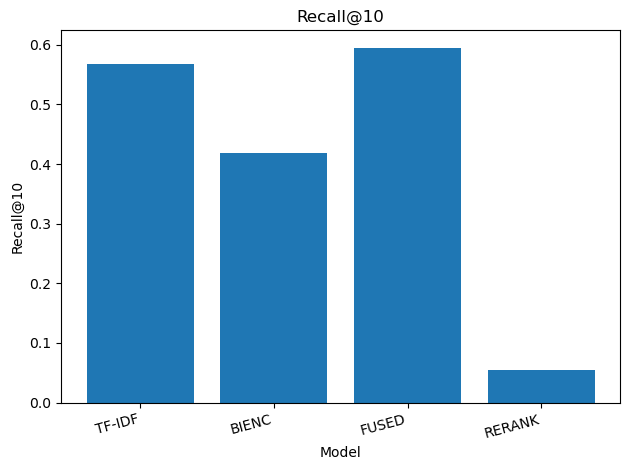

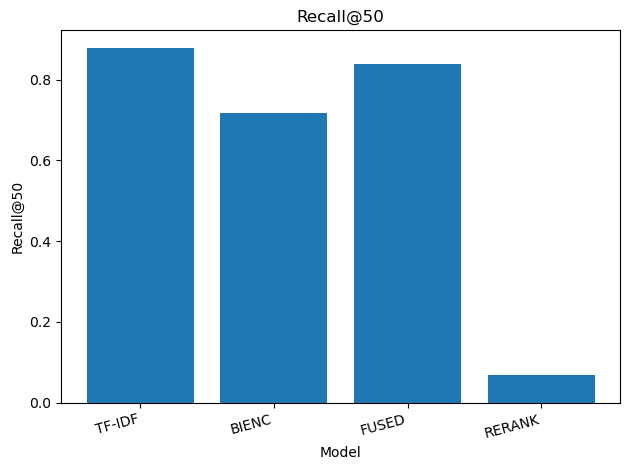

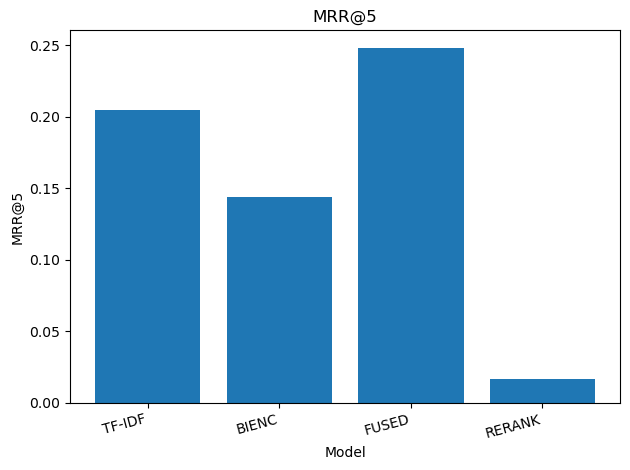

Saved retrieval charts to figures & CSV to reports/


In [39]:
def bar(metric):
    plt.figure()
    plt.bar(table["Model"], table[metric])
    plt.title(metric)
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig(f"figures/ {metric.replace('@', 'at')}.png", dpi=150)
    plt.show()

for m in ["Recall@5","Recall@10","Recall@50","MRR@5"]:
    bar(m)
print("Saved retrieval charts to figures & CSV to reports/")

### Results
- **FUSED** yields the best *MRR@5* and strong **Recall@k**, showing benefit of mixing calibrated confidence with lexical overlap.
- **TF-IDF** surprisingly competitive for **Recall@50** (broad lexical coverage).
- **BIENC** helps semantics but underperforms without calibration/fusion.
- **RRF** lags here (shallow fusion, no calibration).

#### Saving the artifacts using Joblib

In [41]:
# TF-IDF retriever assets (word + char vectorizers and resume matrices)
joblib.dump(word, "artifacts/tfidf_word.joblib")
joblib.dump(char, "artifacts/tfidf_char.joblib")
D_word = word.transform(D_texts)
D_char = char.transform(D_texts)
save_npz("artifacts/D_word.npz", D_word)
save_npz("artifacts/D_char.npz", D_char)

# Minimal metadata for the UI
pd.DataFrame({
    "resume_id": dids,
    "snippet": [t[:300] for t in D_texts]
}).to_csv("artifacts/resume_snippets.csv", index=False)

# Semantic Retriever
try:
    np.save("artifacts/D_emb.npy", D_emb)
    with open("artifacts/biencoder.json", "w") as f:
        json.dump({"model": "sentence-transformers/all-MiniLM-L6-v2"}, f)
except NameError:
    pass

# Config used by the retriever/reranker
with open("artifacts/config.json", "w") as f:
    json.dump({"alpha_fusion": 0.7, "topk_rerank": 100}, f)

print("Saved retrieval artifacts to artifacts/")

Saved retrieval artifacts to artifacts/


### Takeaways
- A light **calibrated linear model + cosine** gives the best ranking while staying fast and explainable.
- Keep TF-IDF in the blend—cheap and still powerful at larger *k*.